In [25]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from zero_point import zpt
import os

In [26]:
hclu = pd.read_csv("/Volumes/travelpassport/litclusterdatabases/HR24/HR24_clusters.csv")
hmem = pd.read_hdf("/Volumes/travelpassport/litclusterdatabases/HR24/HR24_members.h5")


open_cond = (
    (hclu.dist16 < 500) & (hclu.CST > 5) & (hclu.Type == "o") & (hclu.RV.notna())
)
mg_cond = (hclu.dist16 < 500) & (hclu.CST > 10) & (hclu.Type == "m") & (hclu.RV.notna())
cond = open_cond | mg_cond

hclu = hclu.loc[cond].reset_index(drop=True).copy()

hmem = hmem.loc[hmem.Name.isin(hclu.Name)].reset_index(drop=True).copy()

In [ ]:
# hmem.GaiaDR3.to_csv("/Volumes/travelpassport/hmem_GaiaDR3.csv", index=False)
# Joined on Gaia Archive

In [27]:
df = pd.read_csv("/Volumes/travelpassport/tables/hmem_zeropoint_join.csv")
df = df.drop(columns=["hmem_oid"])

In [28]:
hmem = pd.merge(hmem, df, on="GaiaDR3")

In [30]:
g_cond = df.phot_g_mean_mag.between(6, 21)

psc_5p_cond = (df.nu_eff_used_in_astrometry.between(1.1, 1.9)) & (
    df.astrometric_params_solved == 31
)
psc_6p_cond = (df.pseudocolour.between(1.24, 1.72)) & (
    df.astrometric_params_solved == 95
)

valid_cond = g_cond & (psc_5p_cond | psc_6p_cond)

In [37]:
zpt.load_tables()

hmem["zpt"] = np.nan

hmem.loc[valid_cond, "zpt"] = zpt.get_zpt(
    hmem.loc[valid_cond, "phot_g_mean_mag"].values,
    hmem.loc[valid_cond, "nu_eff_used_in_astrometry"].values,
    hmem.loc[valid_cond, "pseudocolour"].values,
    hmem.loc[valid_cond, "ecl_lat"].values,
    hmem.loc[valid_cond, "astrometric_params_solved"].values,
)

In [42]:
hmem.columns

Index(['_RAJ2000', '_DEJ2000', 'recno', 'Seq', 'Name', 'ID', 'GaiaDR3', 'inrj',
       'inrt', 'Prob', 'RA_ICRS', 'e_RA_ICRS', 'DE_ICRS', 'e_DE_ICRS', 'GLON',
       'GLAT', 'pmRA', 'e_pmRA', 'pmDE', 'e_pmDE', 'Plx', 'e_Plx', 'pscol',
       'e_pscol', 'PlxpmRACor', 'PlxpmDECor', 'pmRApmDECor', 'PlxpscolCor',
       'pmRApscolCor', 'pmDEpscolCor', 'Solved', 'ELAT', 'nueff', 'RUWE',
       'FidelityV1', 'FG', 'e_FG', 'FBP', 'e_FBP', 'FRP', 'e_FRP', 'Gmag',
       'BPmag', 'RPmag', 'BP-RP', 'BP-G', 'G-RP', 'RV', 'e_RV', 'n_RV', 'o_RV',
       'o_RVd', 'GRVSmag', 'e_GRVSmag', 'o_GRVSmag', 'Vbroad', 'e_Vbroad',
       'o_Vbroad', 'VarFlag', 'NSS', 'RVS', 'Mass2.5', 'Mass16', 'Mass50',
       'Mass84', 'Mass97.5', '_RA.icrs', '_DE.icrs', 'parallax',
       'parallax_error', 'phot_g_mean_mag', 'nu_eff_used_in_astrometry',
       'pseudocolour', 'ecl_lat', 'astrometric_params_solved', 'zpt'],
      dtype='str')

In [50]:
hmem[
    [
        "Name",
        "GaiaDR3",
        "parallax",
        "parallax_error",
        "zpt",
        "nu_eff_used_in_astrometry",
        "pseudocolour",
        "ecl_lat",
        "astrometric_params_solved",
    ]
].to_csv("../data/hmem_zpt.csv", index=False)

In [45]:
import matplotlib.pyplot as plt

(array([  26.,   38.,   46.,   85.,   74.,  142.,  145.,  233.,  265.,
         297.,  346.,  351.,  379.,  428.,  498.,  581.,  731.,  720.,
         938., 1063., 1033., 1137., 1211., 1324., 1505., 1620., 2250.,
        1790., 1830., 1775., 1819., 2101., 2079., 2315., 2577., 2556.,
        2380., 2255., 1907., 1769., 1695., 1126.,  891.,  768.,  707.,
         589.,  585.,  565.,  533.,  553.,  550.,  554.,  541.,  462.,
         435.,  386.,  346.,  422.,  366.,  219.,  252.,  195.,  132.,
         199.,  139.,   94.,   59.,   74.,   69.,   53.,   70.,   66.,
          45.,   58.,   55.,   54.,   47.,   43.,   48.,   47.,   40.,
          43.,   29.,   49.,   51.,   40.,   46.,   23.,   41.,   37.,
          44.,   33.,   41.,   42.,   29.,   34.,   26.,   23.,   40.,
          26.,   24.,   39.,   21.,   35.,   33.,   30.,   18.,   29.,
          38.,   25.,   34.,   29.,   21.,   15.,   19.,   23.,   24.,
          25.,   23.,   24.,   28.,   16.,   12.,   16.,   14.,   20.,
      

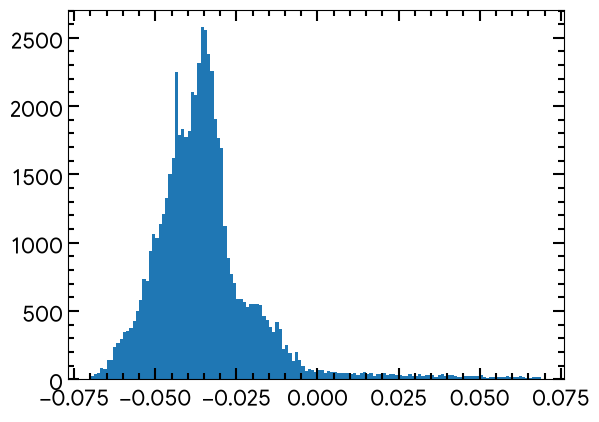

In [49]:
plt.hist(hmem.zpt, bins=np.arange(-0.07, 0.07, 0.001))

<Axes: >

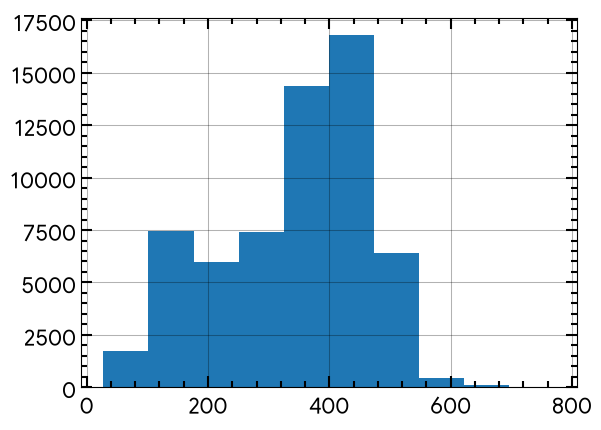

In [40]:
(1000 / (hmem.parallax - hmem.zpt)).hist()

In [17]:
df.astrometric_params_solved.value_counts()

astrometric_params_solved
31    55547
95    20010
Name: count, dtype: int64

In [18]:
import duckdb

In [19]:
df = duckdb.sql("""

    SELECT *

    FROM read_parquet('/Volumes/travelpassport/tables/allskylitjoin/sky_00000074.parquet')

    LIMIT 1000

""").df()

In [21]:
df[["source_id"]].to_csv(
    "/Volumes/travelpassport/sample_stars_for_zero_point.csv", index=False
)

In [22]:
df_zpt = pd.read_csv("/Volumes/travelpassport/samp_zpt_stars.csv")

In [24]:
df_zpt.astrometric_params_solved.value_counts()

astrometric_params_solved
95    666
31    334
Name: count, dtype: int64

<Axes: >

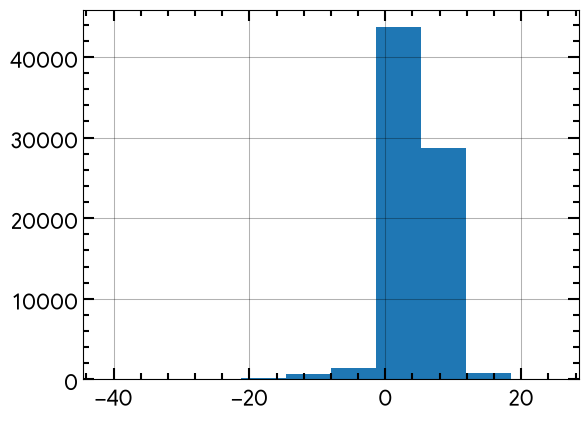

In [31]:
(1000 / df.parallax - (1000 / (df.parallax - df["zpt"]))).hist()